# PCB Signal Integrity Analysis Using PyEDB

This example demonstrates a complete end-to-end PCB signal integrity workflow:

1. Load an existing high-speed digital PCB layout from an EDB file.
2. Explore the board—inspect the stackup, nets, and components.
3. Configure the design using a single JSON file: update stackup materials with
   frequency-dependent properties and surface roughness models, assign measured
   S-parameter data to decoupling capacitors, create coaxial ports on the IC and
   circuit ports on the connector, backdrill via stubs, define a focused design
   cutout, and set up a SIwave AC analysis.
4. Apply the configuration and visualize the result.
5. Open the configured EDB in HFSS 3D Layout, assign differential pairs, and run
   the SIwave solver.
6. Post-process and plot the differential insertion loss (SDD21) for the PCIe
   Gen4 channel.

Keywords: **EDB**, **PyEDB**, **signal integrity**, **SIwave**, **HFSS 3D Layout**,
**PCIe**, **differential pairs**, **S-parameters**

## Prerequisites

### Perform imports

In [1]:
import json
import os
import tempfile
import time

import matplotlib.pyplot as plt
from ansys.aedt.core import Hfss3dLayout
from ansys.aedt.core.examples.downloads import download_file
from pyedb import Edb


### Define constants

Constants help ensure consistency and avoid repetition throughout the example.

In [2]:
AEDT_VERSION = "2025.2"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.

### Create temporary directory

Create a temporary working directory.
The name of the working folder is stored in ``temp_folder.name``.

> **Note:** The final cell in the notebook cleans up the temporary folder. If you want to
> retrieve the AEDT project and data, do so before executing the final cell in the notebook.

In [3]:
temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")

### Download example PCB layout

Download the ANSYS high-speed digital (HSD) PCB reference design. This 16-layer
board includes DDR4 and PCIe Gen4 interfaces, a multi-layer copper/dielectric
stackup, decoupling capacitors, and a BGA IC (U1) connected to an edge connector (X1).

A measured S-parameter file for the decoupling capacitor is also downloaded.

> **Note:** For execution of this example on your local machine, you may
> download or clone the [example-data](https://github.com/ansys/example-data)
> repo and add the
> following lines so that files for this example are copied from that local
> source.

``` python
from ansys.aedt.core import settings
settings.use_local_example_data = True
settings.local_example_folder = r'/path/to/local/example-data'
```

In [4]:
file_edb = download_file(source="pyaedt/edb/ANSYS-HSD_V1.aedb", local_path=temp_folder.name)

In [5]:
download_file(
    source="touchstone",
    name="GRM32_DC0V_25degC_series.s2p",
    local_path=os.path.dirname(file_edb),
)

'C:\\Users\\ansys\\AppData\\Local\\Temp\\tmpn67q42x0.ansys\\pyaedt\\edb\\pyaedt\\touchstone\\GRM32_DC0V_25degC_series.s2p'

## Explore the PCB Layout

Open the PCB as an ``Edb`` instance
and inspect the stackup, nets, and components. This is useful for
identifying the layer names, net names, and
component reference designators that will be referenced later in the configuration.

In [6]:
edbapp = Edb(edbpath=file_edb, version=AEDT_VERSION)

PyEDB INFO: Star initializing Edb 05:06:10.449085


PyEDB INFO: Edb version 2025.2


PyEDB INFO: Logger is initialized. Log file is saved to C:\Users\ansys\AppData\Local\Temp\pyedb_ansys.log.


PyEDB INFO: legacy v0.71.0


PyEDB INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


PyEDB INFO: Database ANSYS-HSD_V1.aedb Opened in 2025.2


PyEDB INFO: Cell main Opened


PyEDB INFO: Builder was initialized.


PyEDB INFO: open_edb completed in 9.5496 seconds.


PyEDB INFO: EDB initialization completed in 9.6605 seconds.


### Inspect the stackup

List all layers with their type and thickness. Layer names returned here are used
verbatim in the ``stackup.layers`` section of the configuration dictionary.

In [7]:
print("Stackup layers:")
for name, layer in edbapp.stackup.layers.items():
    print(f"  '{name}': type={layer.type}, thickness={layer.thickness*1E6:.1f} µm")
    print("--------------------------------------------")

Stackup layers:
  '1_Top': type=signal, thickness=35.0 µm
--------------------------------------------
  'DE1': type=dielectric, thickness=100.0 µm
--------------------------------------------
  'Inner1(GND1)': type=signal, thickness=17.0 µm
--------------------------------------------
  'DE2': type=dielectric, thickness=88.0 µm
--------------------------------------------
  'Inner2(PWR1)': type=signal, thickness=17.0 µm
--------------------------------------------
  'DE3': type=dielectric, thickness=100.0 µm
--------------------------------------------
  'Inner3(Sig1)': type=signal, thickness=17.0 µm
--------------------------------------------
  'Megtron4-1mm': type=dielectric, thickness=1000.0 µm
--------------------------------------------
  'Inner4(Sig2)': type=signal, thickness=17.0 µm
--------------------------------------------
  'DE5': type=dielectric, thickness=100.0 µm
--------------------------------------------
  'Inner5(PWR2)': type=signal, thickness=17.0 µm
-------------

### Inspect nets and components

In [8]:
print(f"\nTotal nets      : {len(edbapp.nets.netlist)}")
print(f"Total components: {len(edbapp.components.instances)}")


Total nets      : 348
Total components: 509


Print the reference designator,
part number and connected net names for components.
Select only the first component instance for
inductors "L", capacitors "C" and the BGA "U".

Count the types of components in the PCB.

In [9]:
resistors = {k: v for k, v in edbapp.components.instances.items() if k.lower().startswith("r")}
caps = {k: v for k, v in edbapp.components.instances.items() if k.lower().startswith("c")}
ics = {k: v for k, v in edbapp.components.instances.items() if k.lower().startswith("u")}
print(f"There are {len(resistors)} resistors, {len(caps)} capacitors and {len(ics)} IC's.")

There are 82 resistors, 380 capacitors and 14 IC's.


Print the reference designator and number of pins for each IC.

In [10]:
for refdes, comp in ics.items():
    s = f"{refdes} has {comp.numpins} pins and is on layer '{comp.placement_layer}'."
    print(s)

U13 has 25 pins and is on layer '1_Top'.
U11 has 11 pins and is on layer '1_Top'.
U10 has 4 pins and is on layer '1_Top'.
U8 has 9 pins and is on layer '1_Top'.
U4 has 39 pins and is on layer '1_Top'.
U3 has 69 pins and is on layer '1_Top'.
U2 has 77 pins and is on layer '16_Bottom'.
U1 has 1517 pins and is on layer '1_Top'.
U6 has 96 pins and is on layer '1_Top'.
U9 has 49 pins and is on layer '1_Top'.
U12 has 24 pins and is on layer '1_Top'.
U15 has 96 pins and is on layer '1_Top'.
U7 has 96 pins and is on layer '1_Top'.
U14 has 96 pins and is on layer '1_Top'.


The BGA is component ``"U1"`` which is an instance of the
``EDBComponent`` class.

Print the bounding box $(x,y)$ coordinates for ``"U1"``.
> **Note:** Lateral
> dimensions are in mm.

In [11]:
refdes = "U1"
x1, y1, x2, y2 = ics[refdes].bounding_box
print_str = f'"{refdes}" bounding box:\n'
print_str += f"      (x={x1*1000:.2f}mm, y={y1*1000:.2f}mm)  lower left\n"
print_str += f"      (x={x2*1000:.2f}mm, y={y2*1000:.2f}mm)  upper right."
print(print_str)

"U1" bounding box:
      (x=60.25mm, y=14.75mm)  lower left
      (x=98.75mm, y=53.25mm)  upper right.


Information about the device pin connections can be accessed
through the ``pins`` property.

In [12]:
ground_pins = [pin for pin, pin_instance in ics[refdes].pins.items() if pin_instance.net.name == "GND"]
print(f'Component "{refdes}" has {len(ground_pins)} pins connected to the net "GND".')

Component "U1" has 403 pins connected to the net "GND".


### Visualize the full board

Plot all nets color-coded by net name to view the copper coverage.

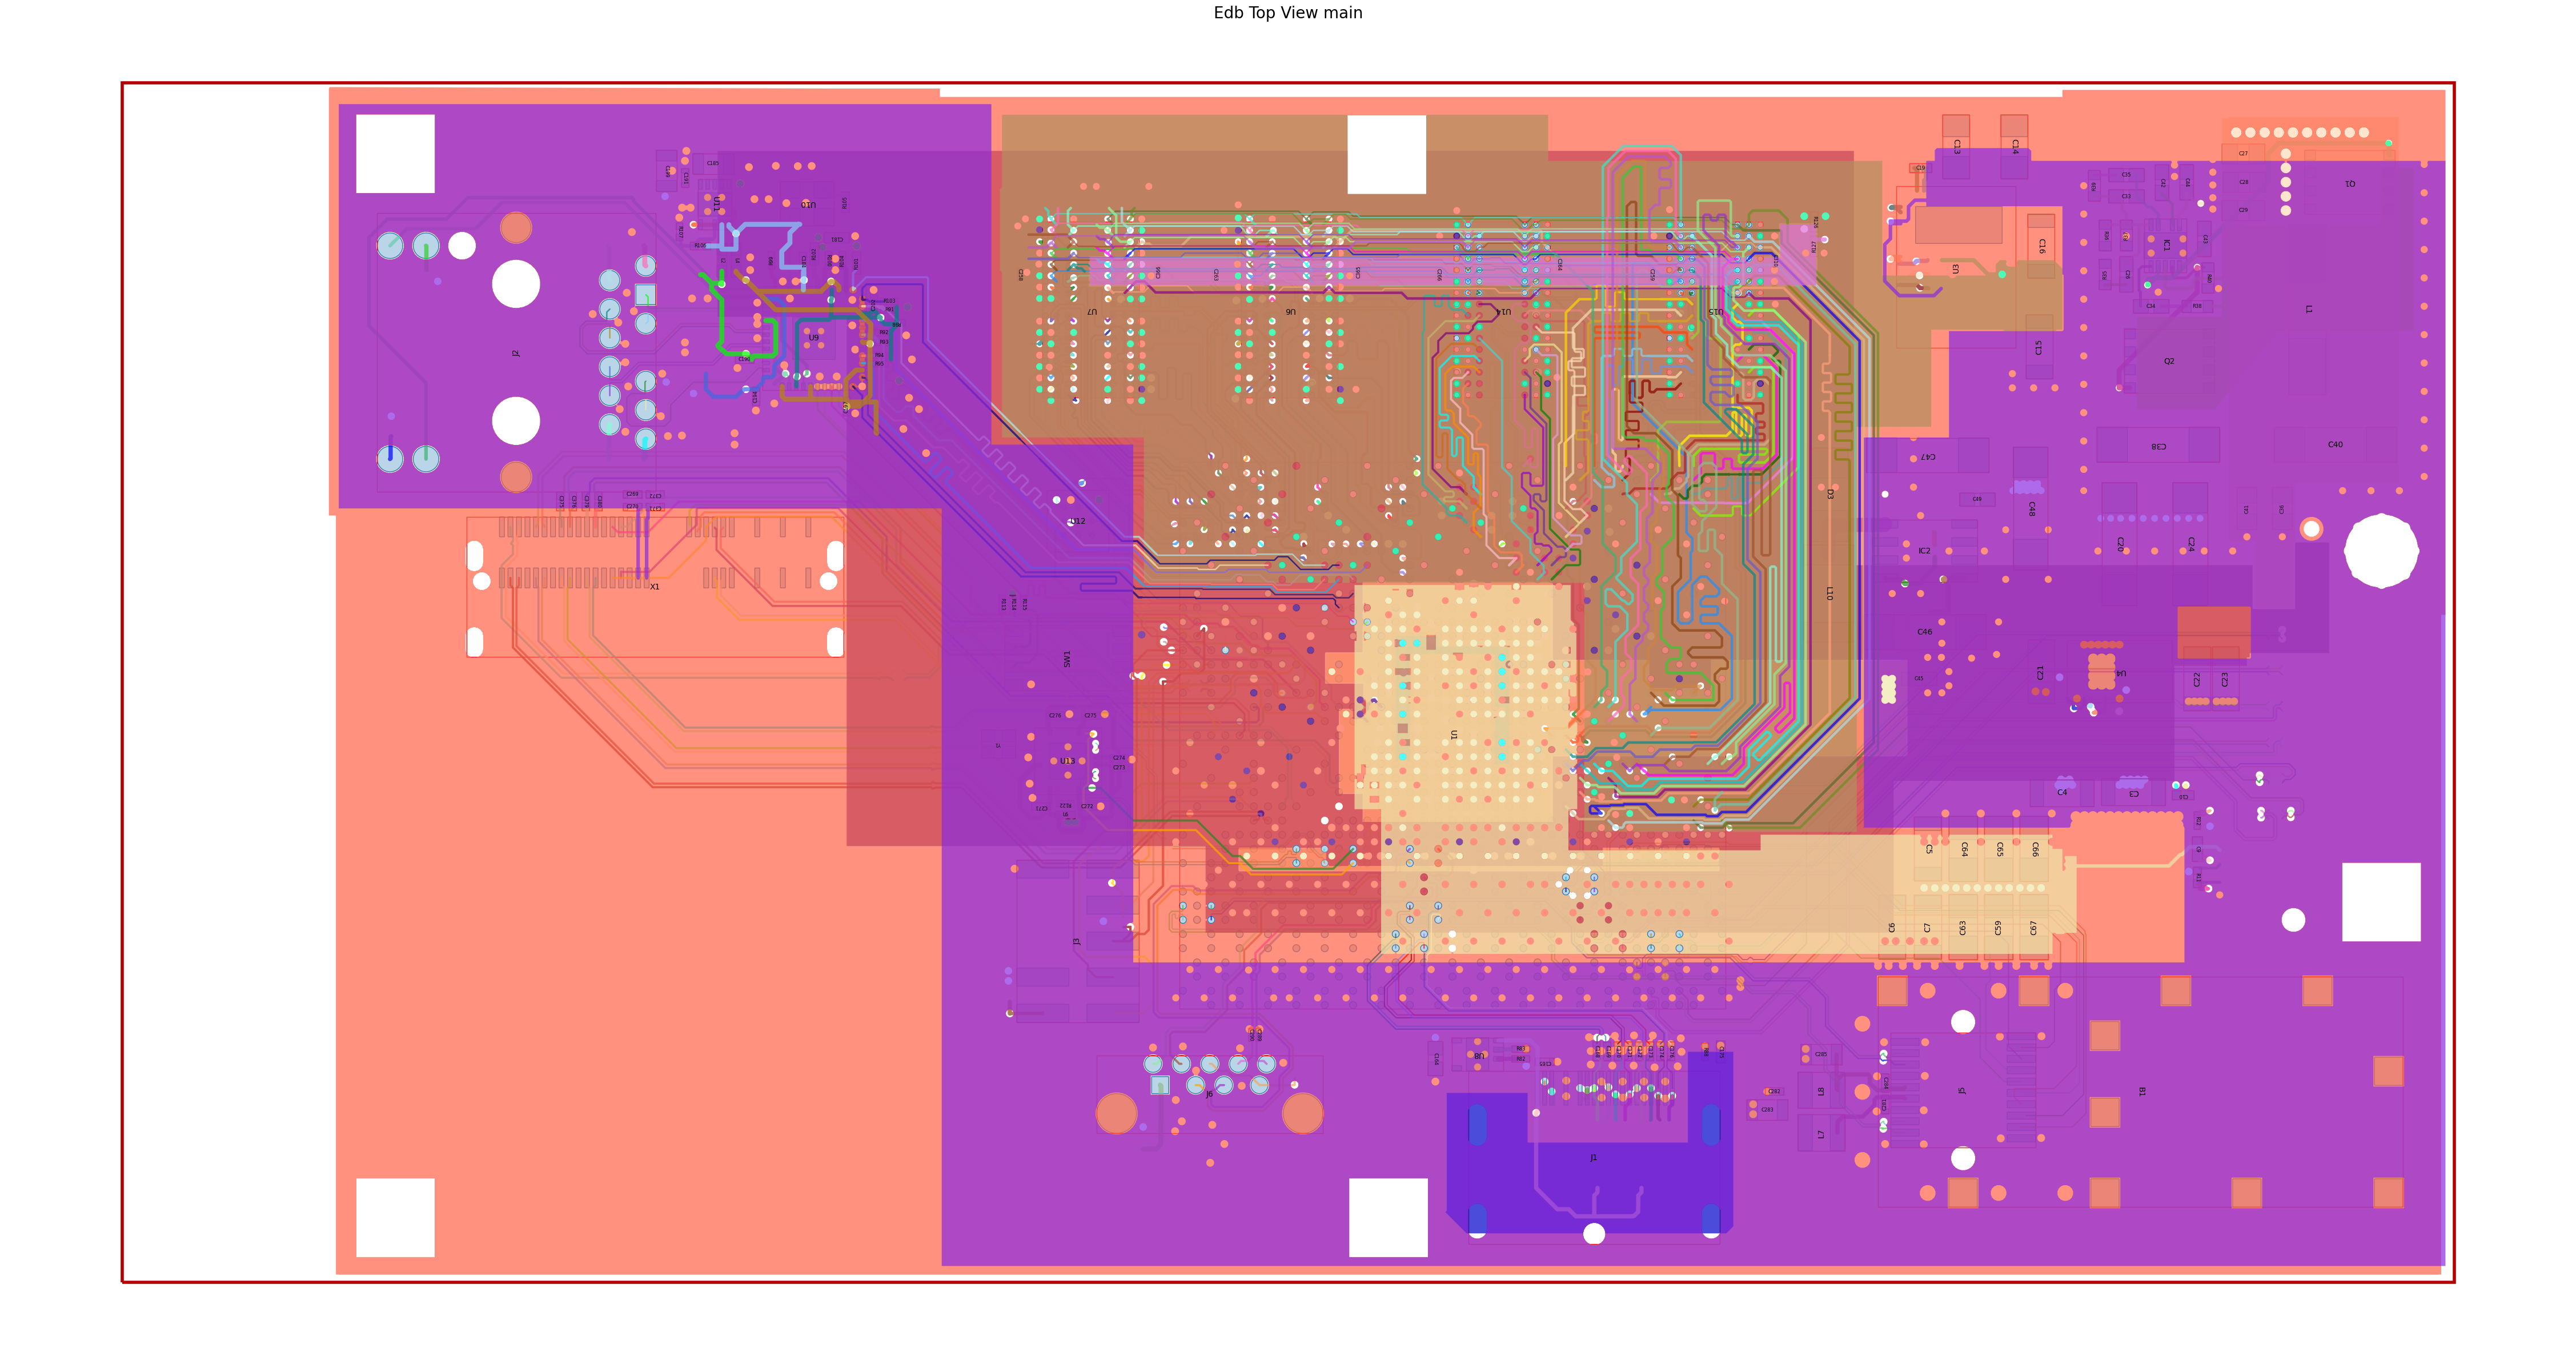

PyEDB INFO: Plot Generation time 39.908


(<Figure size 6000x3000 with 1 Axes>,
 <Axes: title={'center': 'Edb Top View main'}>)

In [13]:
edbapp.nets.plot(None, color_by_net=True, show_legend=False)

Plot the PCB stackup cross-section showing layer thicknesses and materials.

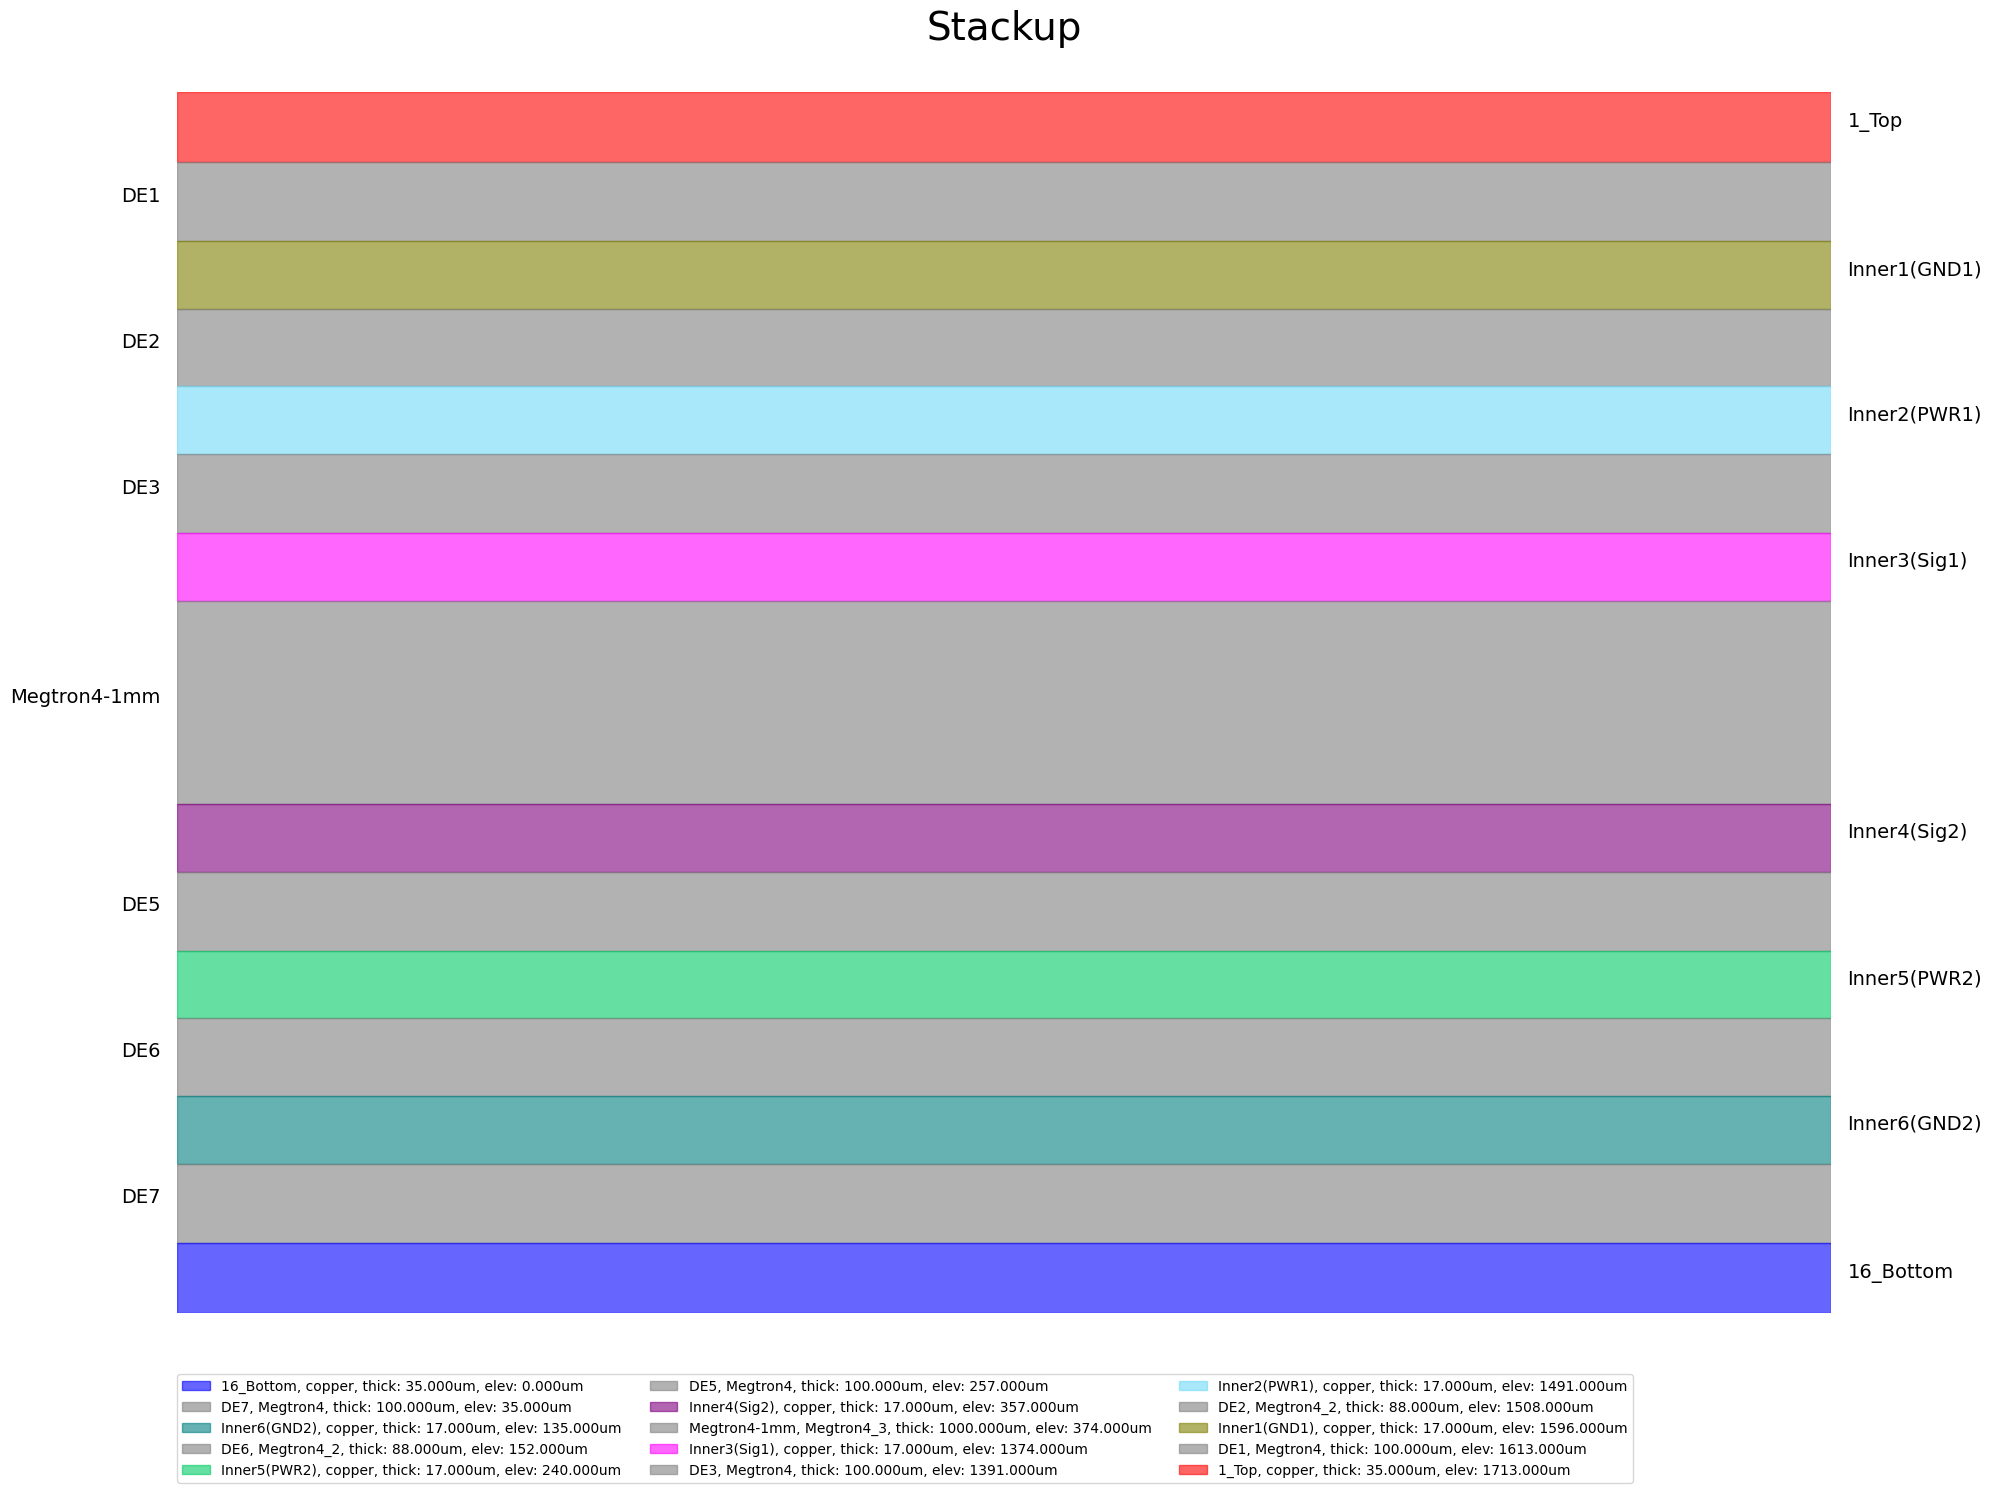

<module 'matplotlib.pyplot' from 'C:\\actions-runner\\_work\\pyaedt-examples\\pyaedt-examples\\.venv\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [14]:
edbapp.stackup.plot()

## Model Preparation

All EDB simulation settings are expressed as a Python dictionary that is
serialized to a JSON file. The ``edb.configuration`` API loads this file and
applies every setting in a single ``run()`` call.

Each subsection below builds one key of the configuration dictionary and
explains the relevant API keywords.

### General settings

- **anti_pads_always_on**: Keep anti-pads (clearances around vias) visible at
  all frequencies. This improves accuracy for high-frequency broadband analysis.
- **suppress_pads**: Remove floating pads on layers where the padstack is not
  connected. This reduces mesh complexity without affecting electrical results.
- **s_parameter_library**: Root folder for S-parameter files referenced by
  relative path in the ``s_parameters`` section.

In [15]:
cfg_general = {
    "anti_pads_always_on": True,
    "suppress_pads": True,
    "s_parameter_library": os.path.join(os.path.dirname(file_edb), "touchstone"),
}

### Update stackup materials

Replace default material assignments with accurate, frequency-dependent values.
Panasonic [Megtron4](https://na.industrial.panasonic.com/products/electronic-materials/circuit-board-materials/lineup/megtron-series/series/127607)
is a common high-performance PCB laminate used in server and networking
boards.

Surface roughness significantly affects insertion loss above ~5 GHz. The Huray
model describes copper roughness using a sphere-on-a-plane geometric
approximation defined by
the nodule radius and the ratio of rough surface area to the ideal flat area.

Keywords for layers:

- **name**: Must match the layer name in the EDB exactly (see stackup inspection above).
- **type**: ``signal`` for copper layers, ``dielectric`` for insulating layers.
- **material**: Conductor or dielectric material name (defined in ``materials``).
- **fill_material**: Dielectric fill between traces on signal layers.
- **thickness**: Layer thickness as a string with units or as a float in meters.
- **roughness.model**: Surface roughness model. ``huray`` is recommended for
  high-frequency PCB analysis.
- **roughness.nodule_radius**: Average radius of copper nodules.
- **roughness.surface_ratio**: Ratio of rough to flat surface area (dimensionless).
- **roughness.enabled**: Set to ``True`` to activate the roughness model.

In [16]:
cfg_stackup = {
    "materials": [
        {"name": "copper", "permittivity": 1.0, "conductivity": 58000000.0},
        {"name": "megtron4", "permittivity": 3.77, "dielectric_loss_tangent": 0.005},
        {"name": "solder_resist", "permittivity": 3.0, "dielectric_loss_tangent": 0.035},
    ],
    "layers": [
        {
            "name": "Top",
            "type": "signal",
            "material": "copper",
            "fill_material": "solder_resist",
            "thickness": "0.035mm",
            "roughness": {
                "top": {"model": "huray", "nodule_radius": "0.5um", "surface_ratio": "5"},
                "bottom": {"model": "huray", "nodule_radius": "0.5um", "surface_ratio": "5"},
                "side": {"model": "huray", "nodule_radius": "0.5um", "surface_ratio": "5"},
                "enabled": True,
            },
        },
        {"name": "DE1", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.1mm"},
        {"name": "Inner1", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "DE2", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.088mm"},
        {"name": "Inner2", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "DE3", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.1mm"},
        {"name": "Inner3", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "Megtron4-1mm", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "1mm"},
        {"name": "Inner4", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "DE5", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.1mm"},
        {"name": "Inner5", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "DE6", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.088mm"},
        {"name": "Inner6", "type": "signal", "material": "copper", "fill_material": "megtron4", "thickness": "0.017mm"},
        {"name": "DE7", "type": "dielectric", "material": "megtron4", "fill_material": "", "thickness": "0.1mm"},
        {
            "name": "Bottom",
            "type": "signal",
            "material": "copper",
            "fill_material": "solder_resist",
            "thickness": "0.035mm",
        },
    ],
}

### Configure the IC component

U1 is the host IC in BGA packaging. Assigning solder ball geometry enables the
configuration framework to automatically create coaxial wave ports on each ball
connected to the specified nets.

Keywords:

- **reference_designator**: Reference designator of the component in the EDB.
- **part_type**: ``io`` for IC drivers/receivers, ``other`` for generic components.
- **solder_ball_properties.shape**: Solder ball cross-section, ``cylinder`` or ``sphere``.
- **solder_ball_properties.diameter** / **height**: Geometry of the solder ball.
- **port_properties.reference_size_auto**: When ``True``, the reference plane
  size is computed automatically from the pitch and ball diameter.

In [17]:
cfg_components = [
    {
        "reference_designator": "U1",
        "part_type": "io",
        "solder_ball_properties": {
            "shape": "cylinder",
            "diameter": "300um",
            "height": "300um",
        },
        "port_properties": {
            "reference_offset": "0",
            "reference_size_auto": True,
            "reference_size_x": 0,
            "reference_size_y": 0,
        },
    }
]

### Assign measured S-parameter models to decoupling capacitors

Measured [Touchstone®](https://ibis.org/touchstone_ver2.1/touchstone_ver2_1.pdf)
data captures real-world parasitic effects (ESL, ESR,
self-resonance) that ideal RLC models cannot represent. This is especially
important for decoupling capacitors in a PDN-aware S-parameter analysis.

Keywords:

- **name**: Label for this S-parameter assignment in the AEDT project.
- **component_definition**: Part number that identifies which component type
  receives this model.
- **file_path**: Touchstone file path, relative to ``general.s_parameter_library``.
- **apply_to_all**: When ``False``, only the components listed in ``components``
  receive the model; all others of the same part type keep their default model.
- **components**: Specific reference designators to assign when ``apply_to_all``
  is ``False``.
- **reference_net**: Net used as the ground reference for the S-parameter model.

In [18]:
cfg_s_parameters = [
    {
        "name": "cap_10nf",
        "component_definition": "CAPC1005X55X25LL05T10",
        "file_path": "GRM32_DC0V_25degC_series.s2p",
        "apply_to_all": True,
        "components": ["C375", "C376"],
        "reference_net": "GND",
    }
]

### Define ports

Create one coaxial port per differential net at the IC ("U1") end, and one circuit
port per differential pair at the connector ("X1") end. The resulting 4-port model
is comprised of
two ports at each end of the the PCIe channel.

Keywords:

- **type**: ``coax`` creates a cylindrical wave port around the solder ball.
  ``circuit`` creates a lumped port between two specified terminals.
- **positive_terminal.net**: For a coax port, the net specifies which solder ball
  on the component is assigned to the port.
- **positive_terminal.pin** / **negative_terminal.pin**: For a circuit port,
  specify the exact pin names (as printed on the component).

In [19]:
cfg_ports = [
    # IC-side coaxial ports on the PCIe Gen4 TX differential pair.
    {
        "name": "port_U1_p",
        "reference_designator": "U1",
        "type": "coax",
        "positive_terminal": {"net": "PCIe_Gen4_TX2_CAP_P"},
    },
    {
        "name": "port_U1_n",
        "reference_designator": "U1",
        "type": "coax",
        "positive_terminal": {"net": "PCIe_Gen4_TX2_CAP_N"},
    },
    # Connector-side circuit ports on the mating edge connector (X1).
    {
        "name": "port_X1_p",
        "reference_designator": "X1",
        "type": "circuit",
        "positive_terminal": {"pin": "B8"},
        "negative_terminal": {"pin": "B7"},
    },
    {
        "name": "port_X1_n",
        "reference_designator": "X1",
        "type": "circuit",
        "positive_terminal": {"pin": "B9"},
        "negative_terminal": {"pin": "B10"},
    },
]

### Configure via backdrills

Via stubs—the unused portion of a through-hole via below the last active
layer—can act as quarter-wave resonators and cause sharp cutouts in insertion
loss at high frequency. Backdrilling removes these stubs after PCB fabrication.

Keywords for instances:

- **name**: Via instance name as it appears in the EDB.
- **backdrill_parameters.from_bottom.drill_to_layer**: Deepest layer reached
  by the backdrilled hole (stub is the portion from this layer to the bottom).
- **backdrill_parameters.from_bottom.diameter**: Diameter of the backdrill bit.
- **backdrill_parameters.from_bottom.stub_length**: Remaining stub length after
  drilling, accounting for tool tolerance.

In [20]:
cfg_padstacks = {
    "definitions": [
        {
            "name": "v40h15-2",
            "material": "copper",
            "hole_range": "upper_pad_to_lower_pad",
            "hole_parameters": {"shape": "circle", "diameter": "0.2mm"},
        },
        {
            "name": "v35h15-1",
            "material": "copper",
            "hole_range": "upper_pad_to_lower_pad",
            "hole_parameters": {"shape": "circle", "diameter": "0.25mm"},
        },
    ],
    "instances": [
        {
            "name": "Via313",
            "backdrill_parameters": {
                "from_bottom": {
                    "drill_to_layer": "Inner3",
                    "diameter": "1mm",
                    "stub_length": "0.2mm",
                }
            },
        },
        {
            "name": "Via314",
            "backdrill_parameters": {
                "from_bottom": {
                    "drill_to_layer": "Inner3",
                    "diameter": "1mm",
                    "stub_length": "0.2mm",
                }
            },
        },
    ],
}

### Define the analysis setup

Use a SIwave AC setup for full-wave S-parameter extraction from 50 MHz to 20 GHz.
This range covers PCIe Gen4 (16 GT/s, Nyquist frequency ~8 GHz) and higher
harmonics that affect eye opening and jitter.

Keywords:

- **type**: ``siwave_ac`` for SIwave SYZ analysis; ``hfss`` for full-wave HFSS.
- **si_slider_position**: Controls the accuracy-vs-speed trade-off.
  ``0`` = speed, ``1`` = balanced (recommended), ``2`` = accuracy.
- **freq_sweep.type**: ``interpolation`` uses adaptive frequency sampling and
  is faster than ``discrete`` for smooth S-parameter curves.
- **frequencies.distribution**: ``linear_scale`` places points uniformly in
  frequency; ``log_scale`` is preferred for PDN impedance plots.

In [21]:
cfg_setups = [
    {
        "name": "siwave_ac",
        "type": "siwave_ac",
        "si_slider_position": 1,
        "freq_sweep": [
            {
                "name": "Sweep1",
                "type": "interpolation",
                "frequencies": [
                    {
                        "distribution": "linear_scale",
                        "start": "50MHz",
                        "stop": "20GHz",
                        "increment": "50MHz",
                    }
                ],
            }
        ],
    }
]

### Define the design cutout

Trim the board to the region containing the PCIe channel. The cutout removes
all copper and dielectric outside the specified polygon, reducing
the required compute resources while retaining the relevant transmission
lines, vias, return-path planes, and decoupling capacitors.

Keywords:

- **signal_list**: Nets that must be fully retained inside the cutout boundary.
- **reference_list**: Reference plane nets (typically ``GND``) that follow the
  signal boundary with their own expansion.
- **custom_extent**: Polygon vertices ``[x_m, y_m]`` in meters that define a
  user-drawn cutout boundary. When omitted, use ``extent_type`` to choose an
  automatic bounding algorithm (``ConvexHull``, ``Conforming``, ``Bounding``).

In [22]:
cfg_operations = {
    "cutout": {
        "signal_list": [
            "PCIe_Gen4_TX2_CAP_P",
            "PCIe_Gen4_TX2_CAP_N",
            "PCIe_Gen4_TX2_P",
            "PCIe_Gen4_TX2_N",
        ],
        "reference_list": ["GND"],
        "custom_extent": [
            [0.014, 0.055],
            [0.03674271504652968, 0.05493094625752912],
            [0.07, 0.039],
            [0.07, 0.034],
            [0.05609890516829415, 0.03395233061637539],
            [0.014, 0.044],
        ],
    }
}

### Assemble configuration dictionary and write to a JSON file

In [23]:
cfg = {
    "general": cfg_general,
    "stackup": cfg_stackup,
    "components": cfg_components,
    "padstacks": cfg_padstacks,
    "ports": cfg_ports,
    "s_parameters": cfg_s_parameters,
    "setups": cfg_setups,
    "operations": cfg_operations,
}

file_json = os.path.join(temp_folder.name, "edb_configuration.json")
with open(file_json, "w") as f:
    json.dump(cfg, f, indent=4, ensure_ascii=False)

### Apply configuration to EDB

``configuration.load()`` reads the JSON file. ``configuration.run()`` applies
every section to the open EDB in the correct dependency order (stackup →
components → padstacks → ports → sources → setups → cutout).

In [24]:
edbapp.configuration.load(config_file=file_json)
edbapp.configuration.run()

PyEDB INFO: Updating nets finished. Time lapse 0:00:00


PyEDB INFO: Updating components finished. Time lapse 0:00:00.031498


PyEDB INFO: Creating pin groups finished. Time lapse 0:00:00


PyEDB INFO: Placing sources finished. Time lapse 0:00:00


PyEDB INFO: Applying materials finished. Time lapse 0:00:00.015908


...

PyEDB INFO: Cutout completed in 1 iterations with expansion size of (0.002)*(1000.0)mm Elapsed time: 0m 8sec


PyEDB INFO: Applying operations completed in 8.4095 seconds.


PyEDB WARNING: sweep_type parameter is deprecated. Use ``discrete`` parameter instead


PyEDB INFO: Applying setups completed in 0.5856 seconds.


True

### Visualize the cutout result

Plot the extracted channel region to confirm that all signal nets and the
surrounding ground planes were retained correctly.

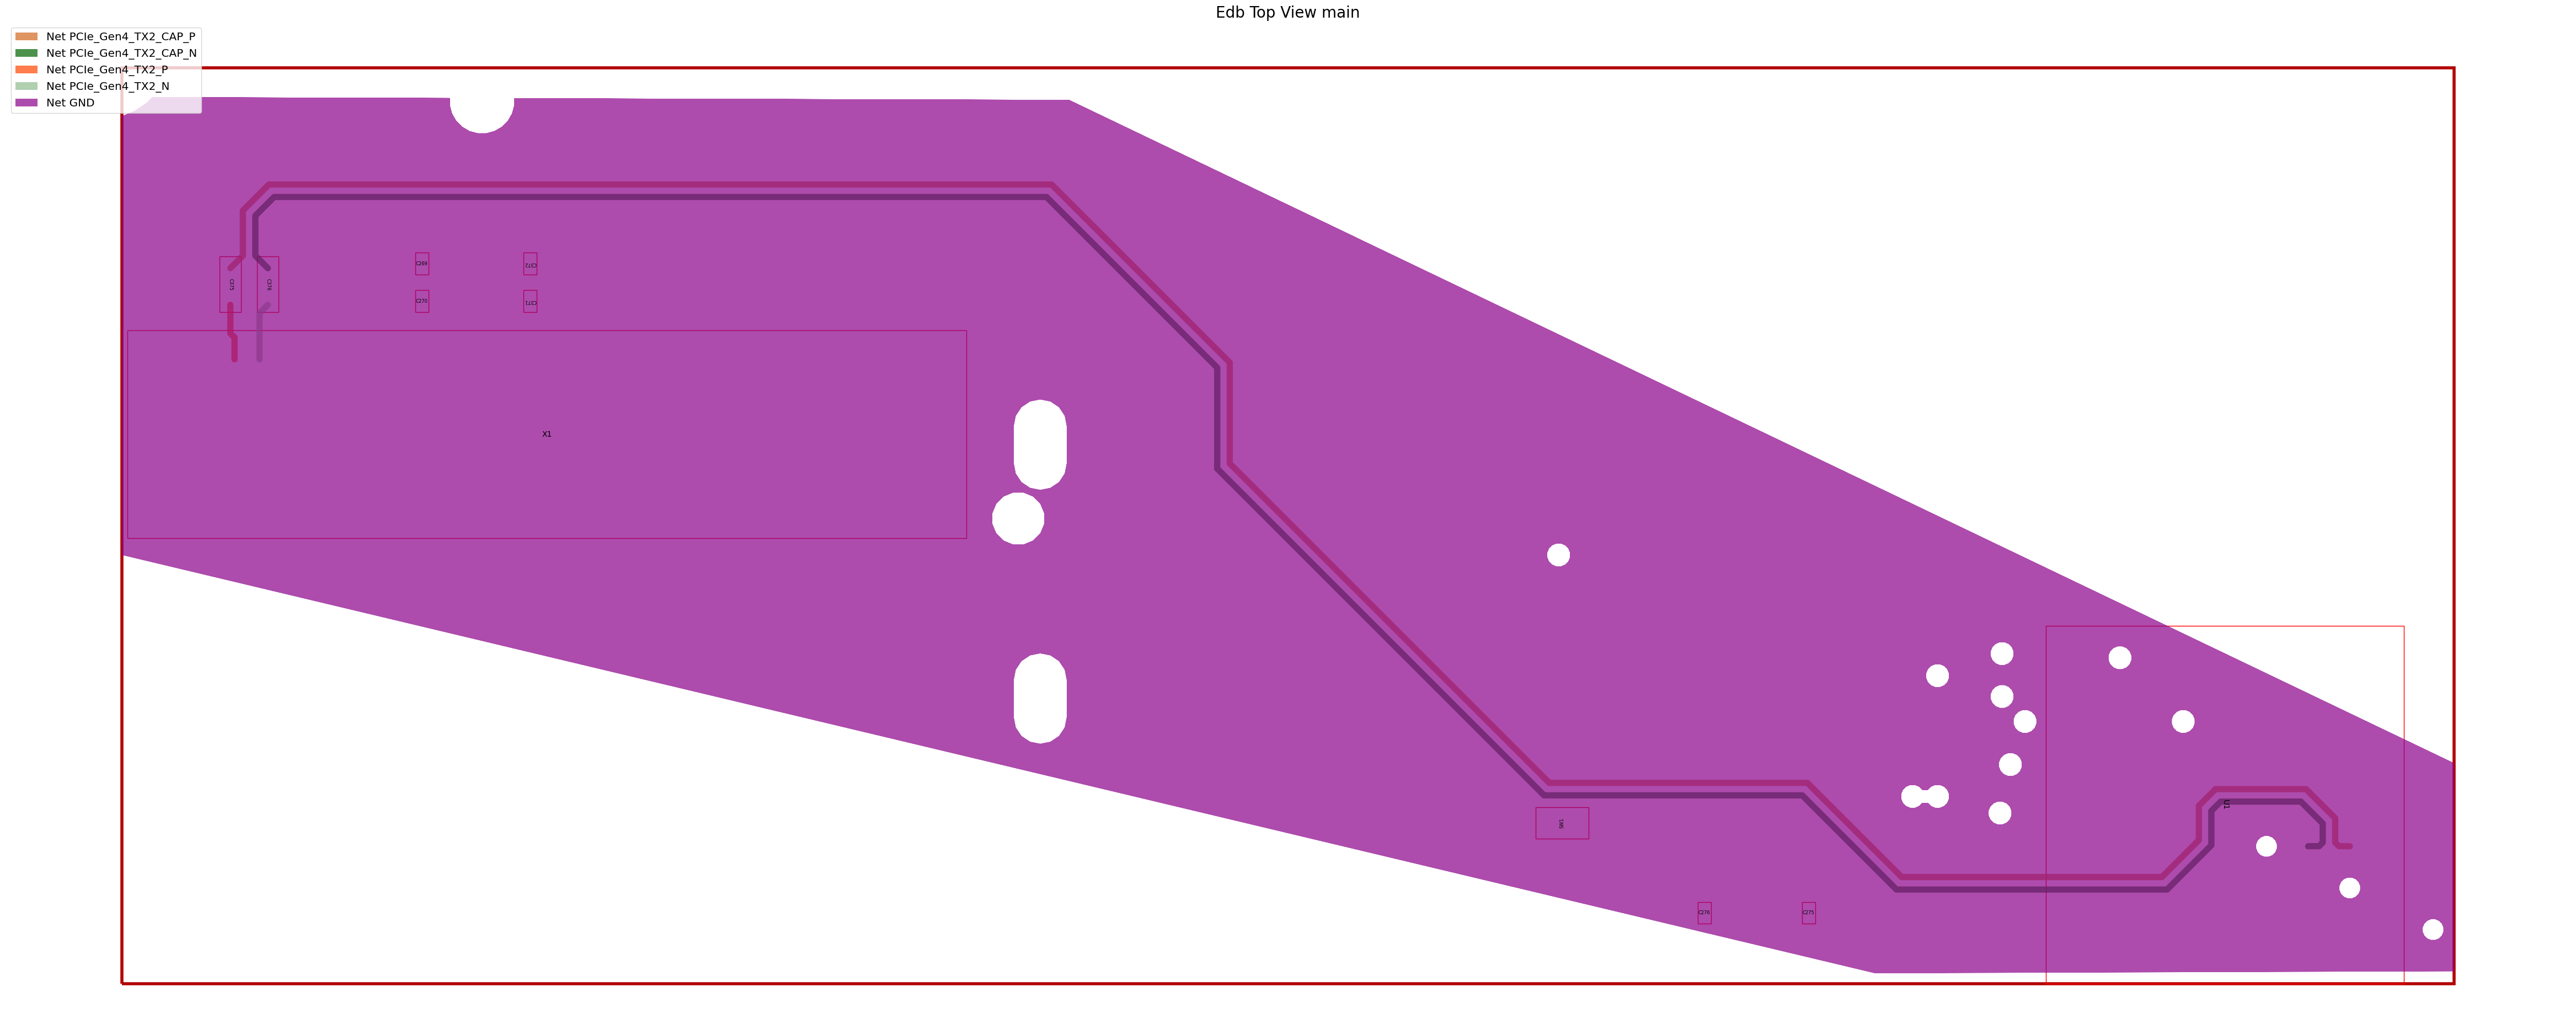

PyEDB INFO: Plot Generation time 0.984


(<Figure size 6000x3000 with 1 Axes>,
 <Axes: title={'center': 'Edb Top View main'}>)

In [25]:
edbapp.nets.plot(
    nets=[
        "PCIe_Gen4_TX2_CAP_P",
        "PCIe_Gen4_TX2_CAP_N",
        "PCIe_Gen4_TX2_P",
        "PCIe_Gen4_TX2_N",
        "GND",
    ],
    color_by_net=True,
)

### Save and close EDB

In [26]:
edbapp.save()
edbapp.close()

PyEDB INFO: Save Edb file completed in 0.0791 seconds.


PyEDB INFO: Close Edb file completed in 0.2059 seconds.


True

## Simulate in HFSS 3D Layout

Open the configured EDB directly in HFSS 3D Layout to drive the SIwave solver.
The same AEDB file is used—no import or conversion step is needed.

In [27]:
h3d = Hfss3dLayout(
    edbapp.edbpath,
    version=AEDT_VERSION,
    non_graphical=NG_MODE,
    new_desktop=True,
)

PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.26.dev0.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: AEDT version 2025.2.


PyAEDT INFO: New AEDT session is starting on gRPC port 64748.


...

PyAEDT WARNING: Service Pack is not detected. PyAEDT is currently connecting in Insecure Mode.


PyAEDT WARNING: Please download and install latest Service Pack to use connect to AEDT in Secure Mode.


PyAEDT INFO: EDB folder C:\Users\ansys\AppData\Local\Temp\tmpn67q42x0.ansys\pyaedt\edb\ANSYS-HSD_V1.aedb has been imported to project ANSYS-HSD_V1


PyAEDT INFO: Active Design set to 0;main


PyAEDT INFO: AEDT objects correctly read


### Defining differential pairs

Map the four single-ended ports defined in the EDB to two mixed-mode ports.
HFSS 3D Layout and SIwave use these definitions to compute differential
(SDD) and common-mode (SCC) S-parameters.

- **differential_mode**: Name of the mixed-mode port (used in result expressions).
- **assignment**: The positive (P) single-ended port name.
- **reference**: The negative (N) single-ended port name.

In [28]:
h3d.set_differential_pair(
    differential_mode="DIFF_U1",
    assignment="port_U1_p",
    reference="port_U1_n",
)

True

In [29]:
h3d.set_differential_pair(
    differential_mode="DIFF_X1",
    assignment="port_X1_p",
    reference="port_X1_n",
)

True

### Run the analysis

In [30]:
h3d.analyze(setup="siwave_ac")

PyAEDT INFO: Project ANSYS-HSD_V1 Saved correctly


PyAEDT INFO: Solving design setup siwave_ac


PyAEDT INFO: Design setup siwave_ac solved correctly in 0.0h 0.0m 52.0s


True

## Postprocess

Extract the mixed-mode S-parameter solution data and plot the differential
insertion loss SDD21. For a PCIe Gen4 channel this should be better than
−3 dB up to the Nyquist frequency (~8 GHz) to meet the channel operating
margin (COM) specification.

### Retrieve solution data

In [31]:
solutions = h3d.post.get_solution_data(
    expressions="mag(S(DIFF_X1,DIFF_U1))",
    context="Differential Pairs",
)

PyAEDT INFO: Parsing C:\Users\ansys\AppData\Local\Temp\tmpn67q42x0.ansys\pyaedt\edb\ANSYS-HSD_V1.aedt.


PyAEDT INFO: File C:\Users\ansys\AppData\Local\Temp\tmpn67q42x0.ansys\pyaedt\edb\ANSYS-HSD_V1.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.4583590030670166


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 1sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 1sec


...

PyEDB INFO: Builder was initialized.


PyEDB INFO: open_edb completed in 0.1199 seconds.


PyEDB INFO: EDB initialization completed in 0.1424 seconds.


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


### Plot differential insertion loss (SDD21)

In [32]:
plot_data = solutions.get_expression_data(convert_to_SI=True, formula="db20")
freq, sdd21_db = plot_data

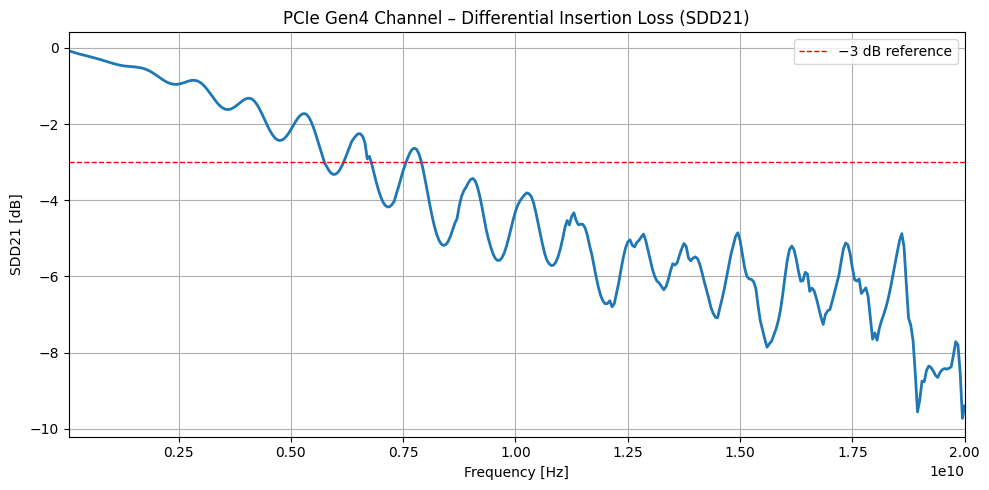

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(freq, sdd21_db, linewidth=2)
plt.axhline(y=-3, color="r", linestyle="--", linewidth=1, label="−3 dB reference")
plt.title("PCIe Gen4 Channel – Differential Insertion Loss (SDD21)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("SDD21 [dB]")
plt.xlim([min(freq), max(freq)])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Finish

### Save the project

In [34]:
h3d.save_project()
h3d.release_desktop()
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

PyAEDT INFO: Project ANSYS-HSD_V1 Saved correctly


PyAEDT INFO: Desktop has been released and closed.


### Clean up

All project files are saved in the folder ``temp_folder.name``.
If you've run this example as a Jupyter notebook, you
can retrieve those project files. The following cell
removes all temporary files, including the project folder.

In [35]:
temp_folder.cleanup()